# Visualizzazione Dataset Anemoi ZARR

Plot di variabili dal dataset WRF convertito in formato Anemoi

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

# Stile plot
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Caricamento Dataset ZARR

In [2]:
# Percorso al dataset ZARR
zarr_path = "/home/lmonaco/CHAPTER/zarr_anemoi/ailam-an-cima-3km-2023-2023-1h-v1.zarr"

# Carica il dataset
ds = xr.open_zarr(zarr_path)
print("Dataset caricato con successo!\n")
print(ds)

/tmp/ipykernel_1123440/3891259490.py:5: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  ds = xr.open_zarr(zarr_path)


Dataset caricato con successo!

<xarray.Dataset> Size: 3GB
Dimensions:     (variable: 149, time: 2, ensemble: 1, cell: 2220273)
Dimensions without coordinates: variable, time, ensemble, cell
Data variables:
    count       (variable) float64 1kB dask.array<chunksize=(149,), meta=np.ndarray>
    data        (time, variable, ensemble, cell) float32 3GB dask.array<chunksize=(1, 149, 1, 2220273), meta=np.ndarray>
    dates       (time) datetime64[s] 16B dask.array<chunksize=(2,), meta=np.ndarray>
    has_nans    (variable) object 1kB dask.array<chunksize=(149,), meta=np.ndarray>
    latitudes   (cell) float64 18MB dask.array<chunksize=(69384,), meta=np.ndarray>
    longitudes  (cell) float64 18MB dask.array<chunksize=(69384,), meta=np.ndarray>
    maximum     (variable) float64 1kB dask.array<chunksize=(149,), meta=np.ndarray>
    mean        (variable) float64 1kB dask.array<chunksize=(149,), meta=np.ndarray>
    minimum     (variable) float64 1kB dask.array<chunksize=(149,), meta=np.ndar

## 2. Esplorazione Struttura Dataset

In [3]:
# Lista variabili disponibili
print("Variabili disponibili:")
for var in ds.data_vars:
    print(f"  - {var}: {ds[var].dims} {ds[var].shape}")

print(f"\nDimensioni:")
for dim in ds.dims:
    print(f"  - {dim}: {ds.dims[dim]}")

print(f"\nCoordinate:")
for coord in ds.coords:
    print(f"  - {coord}: {ds.coords[coord].shape}")
    
# Mostra anche gli attributi del dataset
print(f"\nAttributi dataset:")
for attr, value in ds.attrs.items():
    print(f"  - {attr}: {value}")

Variabili disponibili:
  - count: ('variable',) (149,)
  - data: ('time', 'variable', 'ensemble', 'cell') (2, 149, 1, 2220273)
  - dates: ('time',) (2,)
  - has_nans: ('variable',) (149,)
  - latitudes: ('cell',) (2220273,)
  - longitudes: ('cell',) (2220273,)
  - maximum: ('variable',) (149,)
  - mean: ('variable',) (149,)
  - minimum: ('variable',) (149,)
  - squares: ('variable',) (149,)
  - stdev: ('variable',) (149,)
  - sums: ('variable',) (149,)

Dimensioni:
  - variable: 149
  - time: 2
  - ensemble: 1
  - cell: 2220273

Coordinate:

Attributi dataset:
  - allow_nans: False
  - attribution: CHAPTER Project - CIMA Foundation
  - constant_fields: ['cc_100', 'cc_150', 'cc_50', 'ci', 'lsm', 'sdor', 'slor', 'slt', 'sst', 'z']
  - data_request: {'area': [23.472, -19.972, 60.001, 42.256], 'grid': [None, None], 'param_level': {'pl': [['cc', 50], ['cc', 100], ['cc', 150], ['cc', 200], ['cc', 250], ['cc', 300], ['cc', 400], ['cc', 500], ['cc', 600], ['cc', 700], ['cc', 850], ['cc', 925],

/tmp/ipykernel_1123440/3039183087.py:8: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  - {dim}: {ds.dims[dim]}")


In [4]:
# Info timesteps
if 'time' in ds.dims:
    print(f"Timesteps disponibili: {ds.dims['time']}")
    if 'dates' in ds.data_vars:
        print(f"Date: {ds['dates'].values}")

# Esplora struttura Anemoi
print("\n" + "="*70)
print("STRUTTURA COMPLETA DATASET ANEMOI")
print("="*70)

# Info dimensioni
print("\nDimensioni:")
for dim, size in ds.dims.items():
    print(f"  {dim}: {size}")

# Se il dataset ha un campo 'data' principale
if 'data' in ds.data_vars:
    print("\nIl dataset ha un campo 'data' unificato")
    print(f"Shape: {ds['data'].shape}")
    print(f"Dims: {ds['data'].dims}")
    
# Lista delle variabili da attributi
if 'variables' in ds.attrs:
    variables_list = ds.attrs['variables']
    print(f"\nVariabili disponibili ({len(variables_list)}):")
    for i, var in enumerate(variables_list):
        print(f"  {i:3d}: {var}")

# Info coordinate geografiche
if 'latitudes' in ds.data_vars:
    print(f"\nLatitudes: {ds['latitudes'].shape}")
if 'longitudes' in ds.data_vars:
    print(f"Longitudes: {ds['longitudes'].shape}")

# Altre info utili
print("\nData variables nel dataset:")
for var_name in ds.data_vars:
    var = ds[var_name]
    print(f"  {var_name}: dims={var.dims}, shape={var.shape}")

# Attributi chiave
print("\nAttributi chiave:")
for attr in ['description', 'start_date', 'end_date', 'frequency', 'total_size']:
    if attr in ds.attrs:
        print(f"  {attr}: {ds.attrs[attr]}")

Timesteps disponibili: 2
Date: ['2023-03-28T12:00:00' '2023-03-28T13:00:00']

STRUTTURA COMPLETA DATASET ANEMOI

Dimensioni:
  variable: 149
  time: 2
  ensemble: 1
  cell: 2220273

Il dataset ha un campo 'data' unificato
Shape: (2, 149, 1, 2220273)
Dims: ('time', 'variable', 'ensemble', 'cell')

Variabili disponibili (149):
    0: 10u
    1: 10v
    2: 2d
    3: 2t
    4: cc_100
    5: cc_1000
    6: cc_150
    7: cc_200
    8: cc_250
    9: cc_300
   10: cc_400
   11: cc_50
   12: cc_500
   13: cc_600
   14: cc_700
   15: cc_850
   16: cc_925
   17: ci
   18: lsm
   19: msl
   20: pt_100
   21: pt_1000
   22: pt_150
   23: pt_200
   24: pt_250
   25: pt_300
   26: pt_400
   27: pt_50
   28: pt_500
   29: pt_600
   30: pt_700
   31: pt_850
   32: pt_925
   33: pv_100
   34: pv_1000
   35: pv_150
   36: pv_200
   37: pv_250
   38: pv_300
   39: pv_400
   40: pv_50
   41: pv_500
   42: pv_600
   43: pv_700
   44: pv_850
   45: pv_925
   46: q
   47: q_100
   48: q_1000
   49: q_150
   5

/tmp/ipykernel_1123440/1572264258.py:3: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Timesteps disponibili: {ds.dims['time']}")
/tmp/ipykernel_1123440/1572264258.py:14: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for dim, size in ds.dims.items():
<frozen _collections_abc>:883: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.


## 2b. Plot TUTTE le variabili disponibili (overview rapido)

In [ ]:
# Plot panoramica di TUTTE le variabili/parametri disponibili su MAPPE

# Estrai lat/lon (usa plurale per Anemoi!)
lats = ds['latitudes'].values
lons = ds['longitudes'].values

# Ottieni lista variabili dall'attributo
if 'variables' in ds.attrs and 'data' in ds.data_vars:
    all_params = ds.attrs['variables']
    n_params = len(all_params)
    
    print(f"Trovati {n_params} parametri nel dataset Anemoi")
    
    # Plot griglia di tutte le variabili
    ncols = 3
    nrows = (n_params + ncols - 1) // ncols
    
    fig = plt.figure(figsize=(6*ncols, 5*nrows))
    
    for i, param_name in enumerate(all_params):
        # Crea subplot con proiezione cartopy
        ax = plt.subplot(nrows, ncols, i+1, projection=ccrs.PlateCarree())
        
        # Estrai dato: data[time, variable, ensemble, cell]
        # Prendi primo timestep, variabile i-esima, primo ensemble
        data = ds['data'].isel(time=0, variable=i, ensemble=0).values
        
        # Plot scatter per dati flattened (cell dimension)
        sc = ax.scatter(lons, lats, c=data, cmap='viridis', s=5, 
                      transform=ccrs.PlateCarree())
        plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, shrink=0.7)
        
        # Aggiungi features geografiche
        ax.coastlines(resolution='10m', linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
        ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5)
        ax.set_title(f"{param_name}", fontsize=9, weight='bold')
    
    plt.tight_layout()
    plt.show()
    
else:
    print("Struttura dataset non riconosciuta!")
    print(f"Data vars: {list(ds.data_vars)}")
    print(f"Attrs: {list(ds.attrs.keys())}")

Trovati 149 parametri nel dataset Anemoi


## 3. Plot Variabili Superficie - Primo Timestep

Variabili superficie trovate: ['10u', '10v', '2t', 'msl', 'sp']


/home/lmonaco/CHAPTER/.venv/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


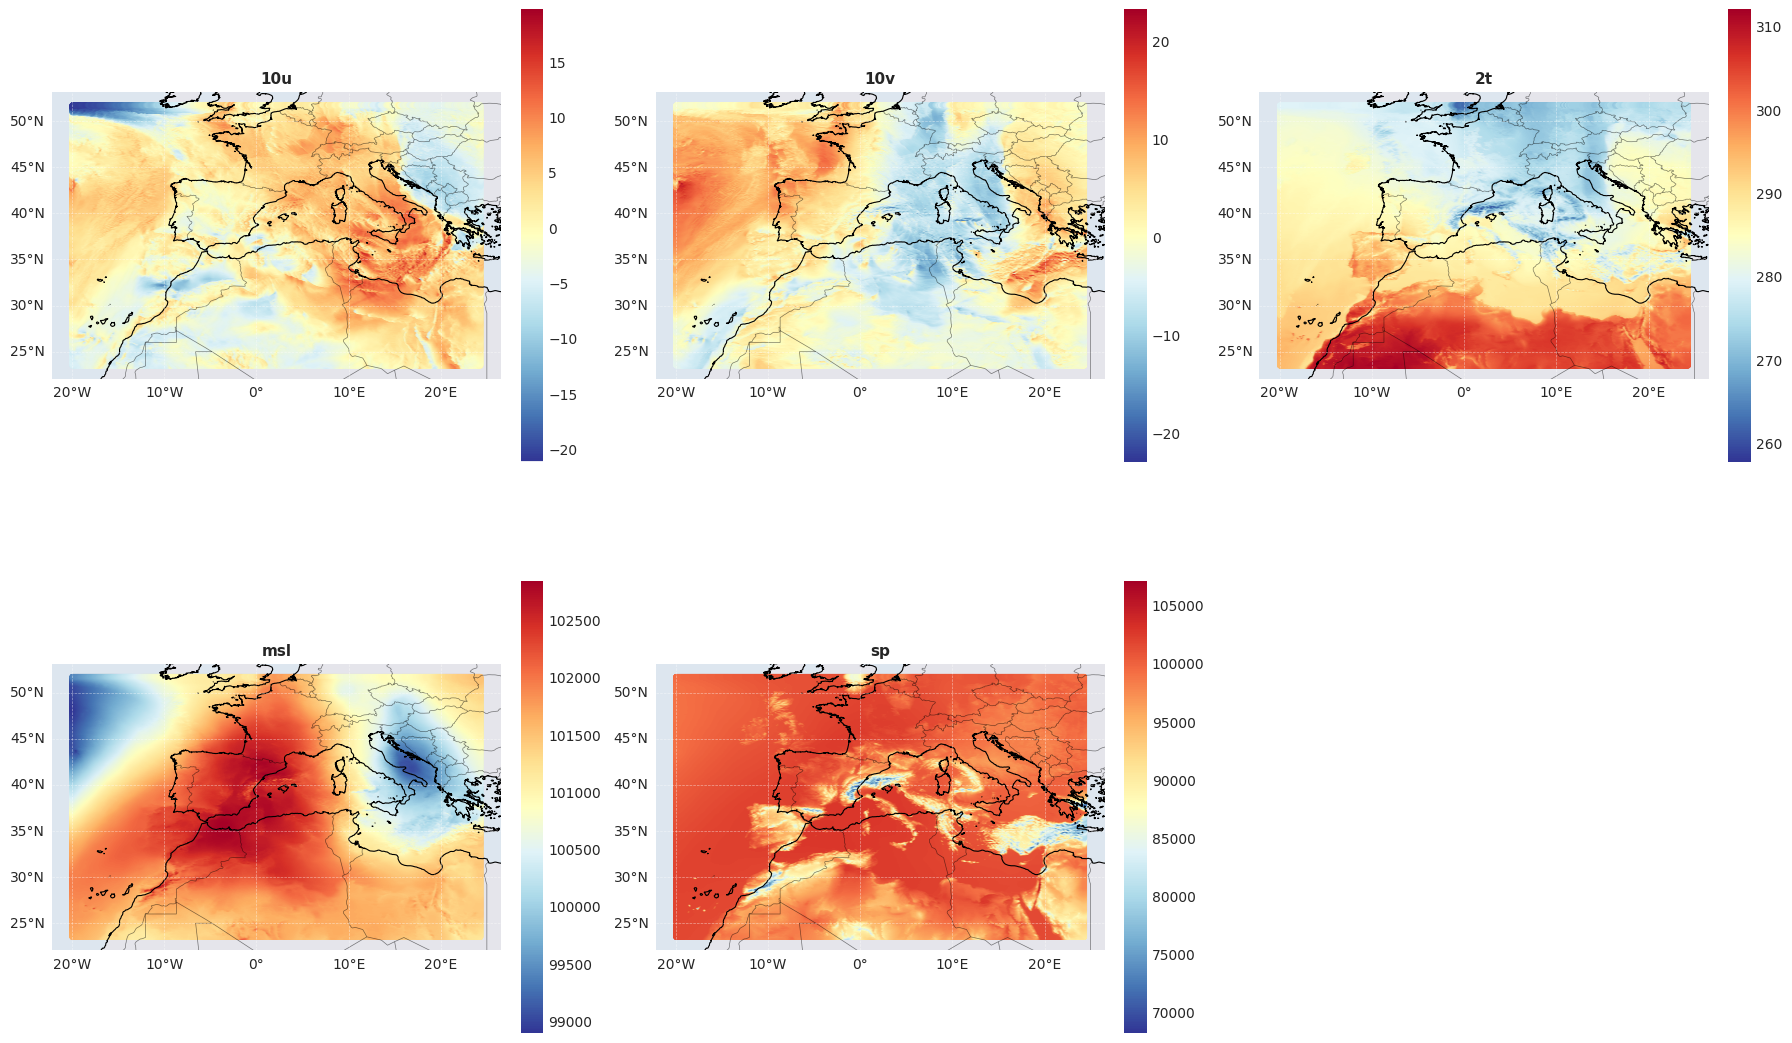

In [5]:
# Selezione primo timestep
time_idx = 0

# Estrai coordinate geografiche (plurale per Anemoi!)
lats = ds['latitudes'].values
lons = ds['longitudes'].values

# Ottieni lista variabili
variables_list = ds.attrs['variables']

# Variabili superficie da plottare
surface_vars_search = ['2t', 't2m', '2m_temperature', 'sp', 'surface_pressure', 'msl', 
                       'mean_sea_level_pressure', '10u', '10v', 'u10', 'v10']

# Trova match con surface_vars_search
surface_to_plot = []
surface_indices = []
for i, var_name in enumerate(variables_list):
    if any(sv.lower() in var_name.lower() or var_name.lower() in sv.lower() for sv in surface_vars_search):
        surface_to_plot.append(var_name)
        surface_indices.append(i)

print(f"Variabili superficie trovate: {surface_to_plot}")

if surface_to_plot:
    n_plots = min(6, len(surface_to_plot))
    fig = plt.figure(figsize=(18, 12))
    
    for plot_idx, (var_name, var_idx) in enumerate(zip(surface_to_plot[:6], surface_indices[:6])):
        # Crea subplot con proiezione
        ax = plt.subplot(2, 3, plot_idx+1, projection=ccrs.PlateCarree())
        
        # Estrai dati: data[time, variable, ensemble, cell]
        data = ds['data'].isel(time=time_idx, variable=var_idx, ensemble=0).values
        
        # Plot su mappa
        sc = ax.scatter(lons, lats, c=data, cmap='RdYlBu_r', s=8,
                      transform=ccrs.PlateCarree())
        plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, shrink=0.8)
        
        # Features geografiche
        ax.coastlines(resolution='10m', linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black', alpha=0.5)
        ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2)
        ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2)
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        
        ax.set_title(f"{var_name}", fontsize=11, weight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Nessuna variabile superficie trovata tra: {variables_list[:20]}...")

## 4. Plot Variabili "Weird" - Sea Ice (ci)

Variabili 'weird' trovate: ['ci', 'lsm', 'sdor', 'sst']

ci:
  Min: 0.0000
  Max: 1.0000
  Mean: 0.0008
  Non-zero values: 1757

lsm:
  Min: 0.0000
  Max: 1.0000
  Mean: 0.5882
  Non-zero values: 1305866

sdor:
  Min: 0.0000
  Max: 417.7925
  Mean: 8.1606
  Non-zero values: 1311996

sst:
  Min: 259.9080
  Max: 308.9990
  Mean: 285.5689
  Non-zero values: 2220273


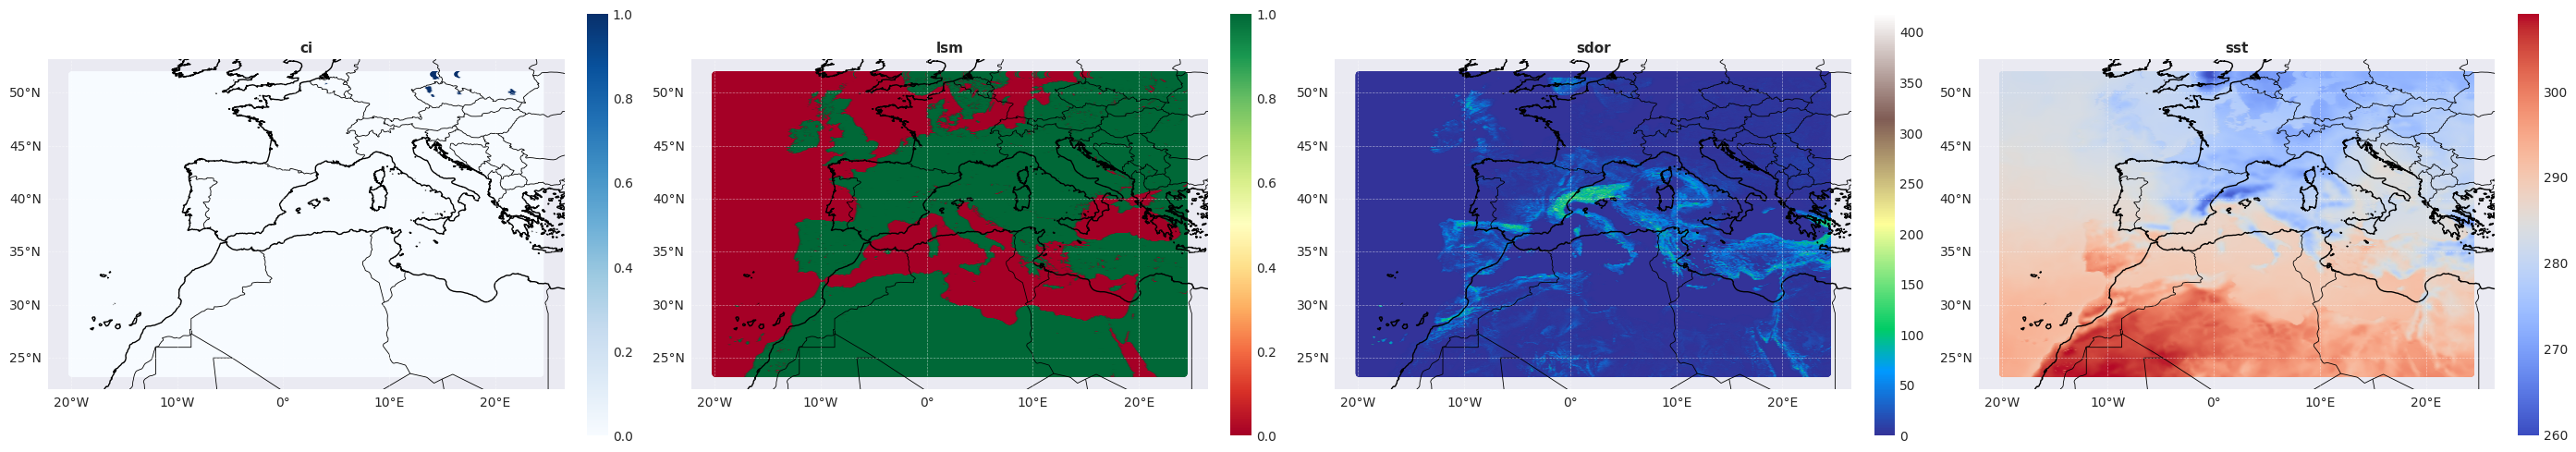

In [6]:
# Variabili "interessanti" o rare da cercare
weird_vars_search = ['ci', 'seaice', 'sea_ice', 'sdor', 'orography', 'lsm', 'land_sea_mask', 
                     'landmask', 'sst', 'sea_surface_temperature']

# Coordinate geografiche
lats = ds['latitudes'].values
lons = ds['longitudes'].values

# Ottieni lista variabili
variables_list = ds.attrs['variables']

# Cerca variabili weird
weird_to_plot = []
weird_indices = []
for i, var_name in enumerate(variables_list):
    if any(wv.lower() in var_name.lower() or var_name.lower() in wv.lower() for wv in weird_vars_search):
        weird_to_plot.append(var_name)
        weird_indices.append(i)

print(f"Variabili 'weird' trovate: {weird_to_plot}")

if weird_to_plot:
    n_vars = len(weird_to_plot)
    fig = plt.figure(figsize=(7*min(n_vars, 4), 6))
    
    for plot_idx, (var_name, var_idx) in enumerate(zip(weird_to_plot[:4], weird_indices[:4])):
        # Crea subplot con proiezione
        ax = plt.subplot(1, min(n_vars, 4), plot_idx+1, projection=ccrs.PlateCarree())
        
        # Estrai dati: data[time, variable, ensemble, cell]
        data = ds['data'].isel(time=time_idx, variable=var_idx, ensemble=0).values
        
        # Scelta colormap
        if 'ice' in var_name.lower() or 'ci' in var_name.lower():
            cmap = 'Blues'
        elif 'land' in var_name.lower() or 'lsm' in var_name.lower():
            cmap = 'RdYlGn'
        elif 'sst' in var_name.lower() or 'temperature' in var_name.lower():
            cmap = 'coolwarm'
        else:
            cmap = 'terrain'
        
        # Plot su mappa
        sc = ax.scatter(lons, lats, c=data, cmap=cmap, s=10,
                      transform=ccrs.PlateCarree())
        plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, shrink=0.8)
        
        # Features geografiche
        ax.coastlines(resolution='10m', linewidth=1)
        ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor='black')
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        
        ax.set_title(f"{var_name}", fontsize=11, weight='bold')
        
        # Statistiche
        print(f"\n{var_name}:")
        print(f"  Min: {float(data.min()):.4f}")
        print(f"  Max: {float(data.max()):.4f}")
        print(f"  Mean: {float(data.mean()):.4f}")
        print(f"  Non-zero values: {np.count_nonzero(data)}")
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Nessuna variabile 'weird' trovata")
    print(f"Variabili disponibili: {variables_list[:20]}...")

## 5. Plot Variabili Orografiche e Statiche

In [ ]:
# Variabili statiche/orografiche
static_vars_search = ['z', 'sdor', 'lsm', 'geopotential', 'orography']

# Coordinate geografiche
lats = ds['latitudes'].values
lons = ds['longitudes'].values

# Ottieni lista variabili
variables_list = ds.attrs['variables']

# Cerca variabili statiche
static_to_plot = []
static_indices = []
for i, var_name in enumerate(variables_list):
    if any(sv.lower() in var_name.lower() or var_name.lower() in sv.lower() for sv in static_vars_search):
        static_to_plot.append(var_name)
        static_indices.append(i)

print(f"Variabili statiche trovate: {static_to_plot}")

if static_to_plot:
    n_vars = len(static_to_plot)
    fig = plt.figure(figsize=(7*n_vars, 6))
    
    for plot_idx, (var_name, var_idx) in enumerate(zip(static_to_plot, static_indices)):
        # Crea subplot con proiezione
        ax = plt.subplot(1, n_vars, plot_idx+1, projection=ccrs.PlateCarree())
        
        # Estrai dati: data[time, variable, ensemble, cell]
        # Per variabili statiche usa primo timestep
        data = ds['data'].isel(time=0, variable=var_idx, ensemble=0).values
        
        # Scelta colormap e titolo
        if 'z' in var_name.lower() and 'sdor' not in var_name.lower():
            cmap = 'terrain'
            title = f'{var_name} - Geopotential/Height'
        elif 'sdor' in var_name.lower():
            cmap = 'YlOrRd'
            title = f'{var_name} - Orography Std Dev'
        elif 'lsm' in var_name.lower() or 'land' in var_name.lower():
            cmap = 'RdYlGn'
            title = f'{var_name} - Land-Sea Mask'
        else:
            cmap = 'viridis'
            title = var_name
        
        # Plot su mappa
        sc = ax.scatter(lons, lats, c=data, cmap=cmap, s=10,
                      transform=ccrs.PlateCarree())
        plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, shrink=0.8)
        
        # Features geografiche
        ax.coastlines(resolution='10m', linewidth=1)
        ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor='black')
        ax.add_feature(cfeature.LAND, facecolor='none', edgecolor='gray', linewidth=0.3)
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        
        ax.set_title(title, fontsize=11, weight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("Nessuna variabile statica trovata")
    print(f"Variabili disponibili: {variables_list[:20]}...")

## 6. Plot Vento a 10m (Vettori)

In [ ]:
# Plot vento come vettori su mappa
# Cerca componenti vento
wind_u_search = ['10u', 'u10', '10m_u']
wind_v_search = ['10v', 'v10', '10m_v']

# Coordinate geografiche
lats = ds['latitudes'].values
lons = ds['longitudes'].values

# Ottieni lista variabili
variables_list = ds.attrs['variables']

# Trova componenti U e V
u_var = None
u_idx = None
v_var = None
v_idx = None

for i, var_name in enumerate(variables_list):
    if u_var is None:
        for search_u in wind_u_search:
            if search_u.lower() in var_name.lower():
                u_var = var_name
                u_idx = i
                break
    
    if v_var is None:
        for search_v in wind_v_search:
            if search_v.lower() in var_name.lower():
                v_var = var_name
                v_idx = i
                break

print(f"Componente U trovata: {u_var} (index {u_idx})")
print(f"Componente V trovata: {v_var} (index {v_idx})")

if u_var and v_var and u_idx is not None and v_idx is not None:
    # Estrai componenti: data[time, variable, ensemble, cell]
    u = ds['data'].isel(time=time_idx, variable=u_idx, ensemble=0).values
    v = ds['data'].isel(time=time_idx, variable=v_idx, ensemble=0).values
    
    # Calcola velocità
    speed = np.sqrt(u**2 + v**2)
    
    fig = plt.figure(figsize=(18, 7))
    
    # Plot 1: Velocità del vento
    ax1 = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
    
    sc = ax1.scatter(lons, lats, c=speed, cmap='viridis', s=10,
                    transform=ccrs.PlateCarree())
    
    ax1.coastlines(resolution='10m', linewidth=1)
    ax1.add_feature(cfeature.BORDERS, linewidth=0.6)
    ax1.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
    gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
    gl1.top_labels = False
    gl1.right_labels = False
    
    plt.colorbar(sc, ax=ax1, fraction=0.046, pad=0.04, shrink=0.8, label='Wind Speed [m/s]')
    ax1.set_title('10m Wind Speed [m/s]', fontsize=12, weight='bold')
    
    # Plot 2: Vettori vento
    ax2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())
    
    # Subsample i dati (troppi vettori sovraccaricano il plot)
    # Prendi ogni N-esimo punto
    step = max(1, len(u) // 150)  # ~150 vettori totali
    u_sub = u[::step]
    v_sub = v[::step]
    speed_sub = speed[::step]
    lons_sub = lons[::step]
    lats_sub = lats[::step]
    
    # Plot colormap di background
    ax2.scatter(lons, lats, c=speed, cmap='plasma', s=5, alpha=0.3,
               transform=ccrs.PlateCarree())
    
    # Aggiungi vettori
    Q = ax2.quiver(lons_sub, lats_sub, u_sub, v_sub, speed_sub,
                  cmap='cool', scale=200, width=0.003,
                  transform=ccrs.PlateCarree())
    
    ax2.coastlines(resolution='10m', linewidth=1, color='black')
    ax2.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor='black')
    ax2.add_feature(cfeature.LAND, facecolor='wheat', alpha=0.3)
    ax2.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)
    gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
    gl2.top_labels = False
    gl2.right_labels = False
    
    ax2.quiverkey(Q, 0.9, 0.95, 10, '10 m/s', labelpos='E', coordinates='axes')
    ax2.set_title('10m Wind Vectors', fontsize=12, weight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n10m Wind Statistics:")
    print(f"  Max speed: {float(speed.max()):.2f} m/s")
    print(f"  Mean speed: {float(speed.mean()):.2f} m/s")
else:
    print("Componenti vento 10m non disponibili")
    print(f"Variabili disponibili: {variables_list[:20]}...")

## 7. Serie Temporale (se disponibili multipli timestep)

In [ ]:
# Check se ci sono multipli timestep
if 'time' in ds.dims and ds.dims['time'] > 1:
    # Variabili per serie temporale
    ts_vars_search = ['2t', 't2m', 'sp', 'msl']
    
    # Ottieni lista variabili
    variables_list = ds.attrs['variables']
    
    # Trova variabili per time series
    ts_to_plot = []
    ts_indices = []
    for i, var_name in enumerate(variables_list):
        if any(ts.lower() in var_name.lower() for ts in ts_vars_search):
            ts_to_plot.append(var_name)
            ts_indices.append(i)
    
    if ts_to_plot:
        fig, axes = plt.subplots(len(ts_to_plot), 1, figsize=(12, 4*len(ts_to_plot)))
        
        if len(ts_to_plot) == 1:
            axes = [axes]
        
        # Estrai dates
        dates = ds['dates'].values
        
        for ax_idx, (var_name, var_idx) in enumerate(zip(ts_to_plot, ts_indices)):
            # Media spaziale per ogni timestep
            # data[time, variable, ensemble, cell] -> media lungo cell
            ts_data = ds['data'].isel(variable=var_idx, ensemble=0).mean(dim='cell').values
            
            axes[ax_idx].plot(dates, ts_data, marker='o', linewidth=2, markersize=8)
            axes[ax_idx].set_xlabel('Time')
            axes[ax_idx].set_ylabel(f'{var_name} (spatial mean)')
            axes[ax_idx].set_title(f'Time Series - {var_name}', fontsize=12, weight='bold')
            axes[ax_idx].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    else:
        print(f"Nessuna variabile trovata per time series")
else:
    print("Un solo timestep disponibile, serie temporale non applicabile")
    print(f"Time dimension size: {ds.dims.get('time', 'N/A')}")

## 8. Summary Statistiche Dataset

In [ ]:
print("="*70)
print("STATISTICHE DATASET COMPLETO")
print("="*70)

# Ottieni lista variabili
variables_list = ds.attrs['variables']

# Usa le statistiche pre-calcolate nel dataset
print(f"\nStatistiche per {len(variables_list)} variabili:\n")

for i, var_name in enumerate(variables_list):
    print(f"{var_name}:")
    print(f"  Min:    {float(ds['minimum'].isel(variable=i).values):.6f}")
    print(f"  Max:    {float(ds['maximum'].isel(variable=i).values):.6f}")
    print(f"  Mean:   {float(ds['mean'].isel(variable=i).values):.6f}")
    print(f"  Stdev:  {float(ds['stdev'].isel(variable=i).values):.6f}")
    print(f"  Count:  {float(ds['count'].isel(variable=i).values):.0f}")
    
    # Check per NaN
    has_nans = ds['has_nans'].isel(variable=i).values
    if has_nans:
        print(f"  ⚠️  Contains NaN values!")
    print()